In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Read the datasets:
We have 2 datasets:
- Kaggle: https://www.kaggle.com/datasets/uciml/el-nino-dataset 
- El Nino indices from 1870: https://psl.noaa.gov/data/timeseries/month/data/nino34.long.anom.csv

In [3]:
elnino = pd.read_csv("elnino.csv")
nino = pd.read_csv("nino34.csv")

### Inspect the datasets

In [4]:
print(elnino.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178080 entries, 0 to 178079
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Observation        178080 non-null  int64  
 1    Year              178080 non-null  int64  
 2    Month             178080 non-null  int64  
 3    Day               178080 non-null  int64  
 4    Date              178080 non-null  int64  
 5    Latitude          178080 non-null  float64
 6    Longitude         178080 non-null  float64
 7    Zonal Winds       178080 non-null  object 
 8    Meridional Winds  178080 non-null  object 
 9    Humidity          178080 non-null  object 
 10   Air Temp          178080 non-null  object 
 11   Sea Surface Temp  178080 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 16.3+ MB
None


In [5]:
print(nino.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1872 entries, 0 to 1871
Data columns (total 2 columns):
 #   Column                                                                       Non-Null Count  Dtype  
---  ------                                                                       --------------  -----  
 0   Date                                                                         1872 non-null   object 
 1      NINA34  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/  1872 non-null   float64
dtypes: float64(1), object(1)
memory usage: 29.4+ KB
None


### Data Cleaning:
Tasks:
- Split ["Date"] in Nino dataset into Year, Month, Day Columnes
- Rename the NINA34  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/ to Nina34
- Rename the Columns in elnino so it contains no space
- Year in elnino display as 80 and nino display year as 1980. Convert so they have the same year display format
- Merge Nino and elnino

In [6]:
# Split date
nino[["Year", "Month", "Day"]] = nino["Date"].str.split("-", expand=True)

In [7]:
# Rename    NINA34  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/ column
nino = nino.rename(columns={"   NINA34  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/": "NINA34"})

In [8]:
# Replace missing values -99.99 with NaN in NINA34
nino["NINA34"] = nino["NINA34"].replace(-99.99, np.nan)

In [9]:
# Strip whitespace in columns name in elnino dataset
elnino.columns = elnino.columns.str.strip()

In [10]:
#Convert elnino year format
elnino["Year"] = elnino["Year"] + 1900

In [11]:
elnino
nino

,Date,NINA34,Year,Month,Day
0,1870-01-01,-1.00,1870,01,01
1,1870-02-01,-1.20,1870,02,01
2,1870-03-01,-0.83,1870,03,01
3,1870-04-01,-0.81,1870,04,01
4,1870-05-01,-1.27,1870,05,01
...,...,...,...,...,...
1867,2025-08-01,-0.11,2025,08,01
1868,2025-09-01,-0.30,2025,09,01
1869,2025-10-01,-0.50,2025,10,01
1870,2025-11-01,-0.68,2025,11,01


In [12]:
# Convert value type
elnino["Year"]  = pd.to_numeric(elnino["Year"], errors="coerce").astype("Int64")
elnino["Month"] = pd.to_numeric(elnino["Month"], errors="coerce").astype("Int64")

nino["Year"]  = pd.to_numeric(nino["Year"], errors="coerce").astype("Int64")
nino["Month"] = pd.to_numeric(nino["Month"], errors="coerce").astype("Int64")

elnino["Zonal Winds"] = pd.to_numeric(elnino["Zonal Winds"], errors="coerce")
elnino["Meridional Winds"] = pd.to_numeric(elnino["Meridional Winds"], errors="coerce")
elnino["Humidity"] = pd.to_numeric(elnino["Humidity"], errors="coerce")
elnino["Air Temp"] = pd.to_numeric(elnino["Air Temp"], errors="coerce")
elnino["Sea Surface Temp"] = pd.to_numeric(elnino["Sea Surface Temp"], errors="coerce")


In [13]:
# Merge datasets
elnino = elnino.merge(nino, on=["Year","Month"])
elnino

,Observation,Year,Month,Day_x,Date_x,Latitude,Longitude,Zonal Winds,Meridional Winds,Humidity,Air Temp,Sea Surface Temp,Date_y,NINA34,Day_y
0,1,1980,3,7,800307,-0.02,-109.46,-6.8,0.7,NaN,26.14,26.24,1980-03-01,0.09,01
1,2,1980,3,8,800308,-0.02,-109.46,-4.9,1.1,NaN,25.66,25.97,1980-03-01,0.09,01
2,3,1980,3,9,800309,-0.02,-109.46,-4.5,2.2,NaN,25.69,25.28,1980-03-01,0.09,01
3,4,1980,3,10,800310,-0.02,-109.46,-3.8,1.9,NaN,25.57,24.31,1980-03-01,0.09,01
4,5,1980,3,11,800311,-0.02,-109.46,-4.2,1.5,NaN,25.30,23.19,1980-03-01,0.09,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178075,178076,1998,6,11,980611,8.96,-140.33,-5.1,-0.4,94.1,26.04,28.14,1998-06-01,-0.39,01
178076,178077,1998,6,12,980612,8.96,-140.32,-4.3,-3.3,93.2,25.80,27.87,1998-06-01,-0.39,01
178077,178078,1998,6,13,980613,8.95,-140.34,-6.1,-4.8,81.3,27.17,27.93,1998-06-01,-0.39,01
178078,178079,1998,6,14,980614,8.96,-140.33,-4.9,-2.3,76.2,27.36,28.03,1998-06-01,-0.39,01


In [14]:
#Remove . 
elnino.replace(".",np.nan, inplace =True)

In [15]:
elnino

,Observation,Year,Month,Day_x,Date_x,Latitude,Longitude,Zonal Winds,Meridional Winds,Humidity,Air Temp,Sea Surface Temp,Date_y,NINA34,Day_y
0,1,1980,3,7,800307,-0.02,-109.46,-6.8,0.7,NaN,26.14,26.24,1980-03-01,0.09,01
1,2,1980,3,8,800308,-0.02,-109.46,-4.9,1.1,NaN,25.66,25.97,1980-03-01,0.09,01
2,3,1980,3,9,800309,-0.02,-109.46,-4.5,2.2,NaN,25.69,25.28,1980-03-01,0.09,01
3,4,1980,3,10,800310,-0.02,-109.46,-3.8,1.9,NaN,25.57,24.31,1980-03-01,0.09,01
4,5,1980,3,11,800311,-0.02,-109.46,-4.2,1.5,NaN,25.30,23.19,1980-03-01,0.09,01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178075,178076,1998,6,11,980611,8.96,-140.33,-5.1,-0.4,94.1,26.04,28.14,1998-06-01,-0.39,01
178076,178077,1998,6,12,980612,8.96,-140.32,-4.3,-3.3,93.2,25.80,27.87,1998-06-01,-0.39,01
178077,178078,1998,6,13,980613,8.95,-140.34,-6.1,-4.8,81.3,27.17,27.93,1998-06-01,-0.39,01
178078,178079,1998,6,14,980614,8.96,-140.33,-4.9,-2.3,76.2,27.36,28.03,1998-06-01,-0.39,01


In [16]:
elnino = elnino.drop(columns=["Day_y","Date_y"])
elnino = elnino.rename(columns={"Day_x": "Day","Date_x":"Date","NINA34_x":"NINA34"})

In [17]:
features = ["Zonal Winds", "Meridional Winds", "Humidity", "Air Temp", "Sea Surface Temp"]


# for feature in features:
#     data[feature] = pd.to_numeric(data[feature], errors="coerce")


In [18]:
elnino.dropna(subset=["Humidity","Zonal Winds","Meridional Winds","Air Temp","Sea Surface Temp"], inplace=True)
X = elnino[features]
y = elnino["NINA34"]

elnino.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93935 entries, 4059 to 178078
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Observation       93935 non-null  int64  
 1   Year              93935 non-null  Int64  
 2   Month             93935 non-null  Int64  
 3   Day               93935 non-null  int64  
 4   Date              93935 non-null  int64  
 5   Latitude          93935 non-null  float64
 6   Longitude         93935 non-null  float64
 7   Zonal Winds       93935 non-null  float64
 8   Meridional Winds  93935 non-null  float64
 9   Humidity          93935 non-null  float64
 10  Air Temp          93935 non-null  float64
 11  Sea Surface Temp  93935 non-null  float64
 12  NINA34            93935 non-null  float64
dtypes: Int64(2), float64(8), int64(3)
memory usage: 10.2 MB


In [19]:
# Check for NaN values in the dataframe
print("Number of NaN values per column:")
print(elnino.isnull().sum())
print("\nTotal NaN values:", elnino.isnull().sum().sum())
print("\nColumns with NaN values:")
print(elnino.columns[elnino.isnull().any()])

Number of NaN values per column:
Observation         0
Year                0
Month               0
Day                 0
Date                0
Latitude            0
Longitude           0
Zonal Winds         0
Meridional Winds    0
Humidity            0
Air Temp            0
Sea Surface Temp    0
NINA34              0
dtype: int64

Total NaN values: 0

Columns with NaN values:
Index([], dtype='object')


In [20]:
elnino

,Observation,Year,Month,Day,Date,Latitude,Longitude,Zonal Winds,Meridional Winds,Humidity,Air Temp,Sea Surface Temp,NINA34
4059,4060,1993,5,9,930509,-0.02,-109.96,-2.1,2.1,81.2,26.80,27.02,0.93
4060,4061,1993,5,10,930510,-0.02,-109.96,-3.4,1.4,84.2,26.95,26.91,0.93
4061,4062,1993,5,11,930511,-0.02,-109.96,-3.8,2.2,84.9,26.98,26.78,0.93
4062,4063,1993,5,12,930512,-0.02,-109.96,-3.0,1.5,86.9,26.93,26.74,0.93
4063,4064,1993,5,13,930513,-0.02,-109.96,-4.5,1.9,87.6,27.01,26.82,0.93
...,...,...,...,...,...,...,...,...,...,...,...,...,...
178074,178075,1998,6,10,980610,8.95,-140.33,-6.8,-5.3,81.3,27.52,28.17,-0.39
178075,178076,1998,6,11,980611,8.96,-140.33,-5.1,-0.4,94.1,26.04,28.14,-0.39
178076,178077,1998,6,12,980612,8.96,-140.32,-4.3,-3.3,93.2,25.80,27.87,-0.39
178077,178078,1998,6,13,980613,8.95,-140.34,-6.1,-4.8,81.3,27.17,27.93,-0.39


In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [22]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R² Score:", r2)

Mean Squared Error: 0.6327905206566954
R² Score: 0.08329765803367994


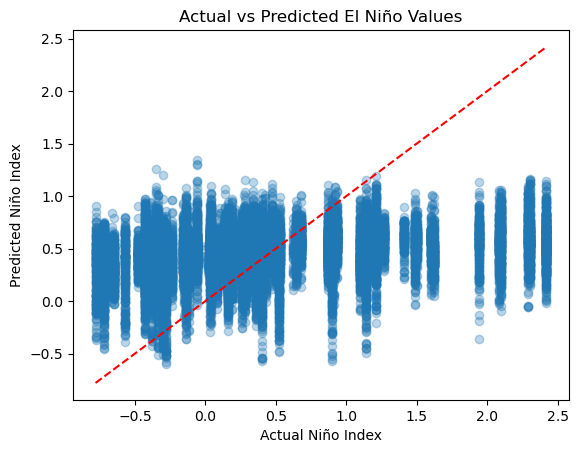

In [23]:
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')

plt.xlabel("Actual Niño Index")
plt.ylabel("Predicted Niño Index")
plt.title("Actual vs Predicted El Niño Values")

plt.show()

In [24]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coefficients)

            Feature  Coefficient
0       Zonal Winds     0.031073
1  Meridional Winds     0.014293
2          Humidity     0.016420
3          Air Temp     0.195757
4  Sea Surface Temp    -0.061026


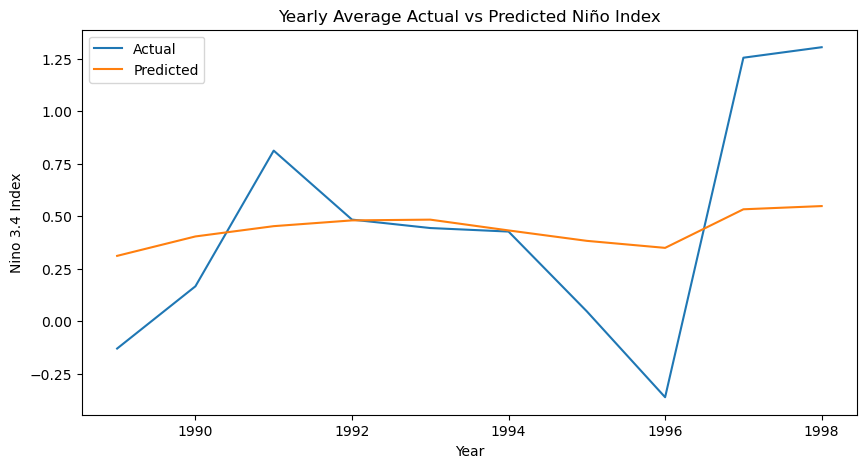

In [25]:
results = pd.DataFrame({
    "Year": elnino.loc[y_test.index, "Year"],
    "Actual": y_test,
    "Predicted": y_pred
})

yearly = results.groupby("Year")[["Actual","Predicted"]].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(yearly["Year"], yearly["Actual"], label="Actual")
plt.plot(yearly["Year"], yearly["Predicted"], label="Predicted")

plt.xlabel("Year")
plt.ylabel("Nino 3.4 Index")
plt.title("Yearly Average Actual vs Predicted Niño Index")

plt.legend()
plt.show()

In [26]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Initialize model
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf.predict(X_test)

# Evaluate model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest MSE:", mse_rf)
print("Random Forest R2:", r2_rf)

Random Forest MSE: 0.542132326041944
Random Forest R2: 0.21463113508313858


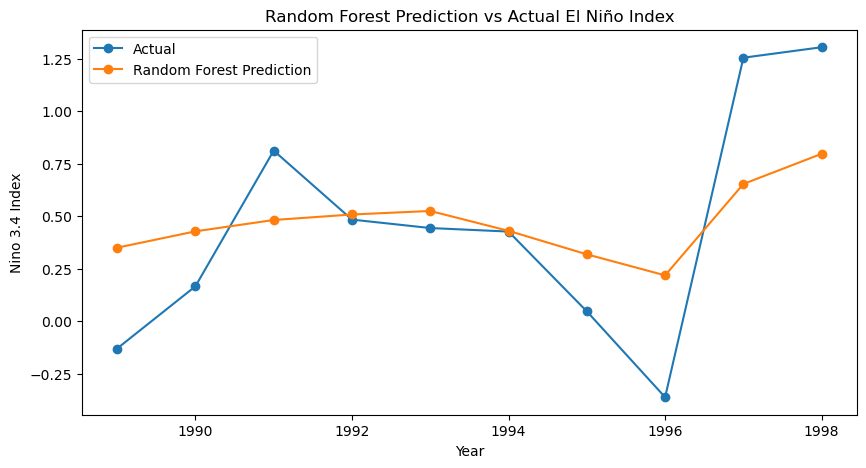

In [27]:
import matplotlib.pyplot as plt
import pandas as pd

results_rf = pd.DataFrame({
    "Year": elnino.loc[y_test.index, "Year"],
    "Actual": y_test,
    "Predicted": y_pred_rf
})

results_rf = results_rf.sort_values("Year")

# Yearly average to reduce noise
yearly_rf = results_rf.groupby("Year")[["Actual","Predicted"]].mean().reset_index()

plt.figure(figsize=(10,5))

plt.plot(yearly_rf["Year"], yearly_rf["Actual"], marker='o', label="Actual")
plt.plot(yearly_rf["Year"], yearly_rf["Predicted"], marker='o', label="Random Forest Prediction")

plt.xlabel("Year")
plt.ylabel("Nino 3.4 Index")
plt.title("Random Forest Prediction vs Actual El Niño Index")

plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

trees = [10, 50, 100, 200]
rmse_scores = []

for n in trees:
    
    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=42
    )
    
    rf.fit(X_train, y_train)
    
    preds = rf.predict(X_test)
    
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    rmse_scores.append(rmse)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(trees, rmse_scores, marker='o')

plt.title("Random Forest Hyperparameter Sensitivity")
plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("RMSE")

plt.show()

In [ ]:
from sklearn.metrics import r2_score

print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))